Najbardziej istotne cechy to indeksy: [ 0  4 14]


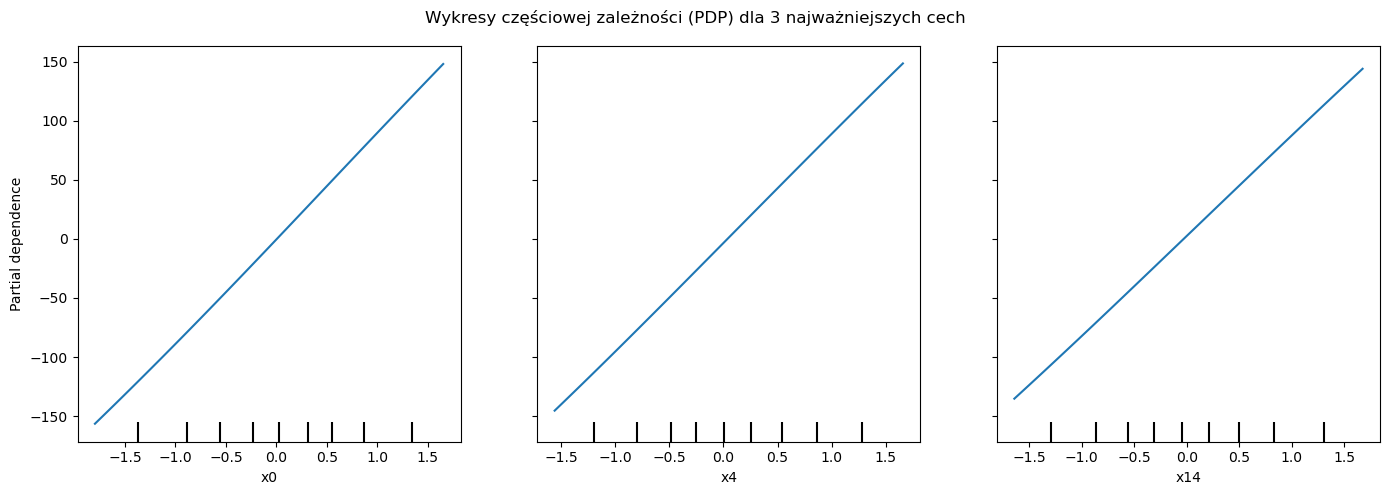

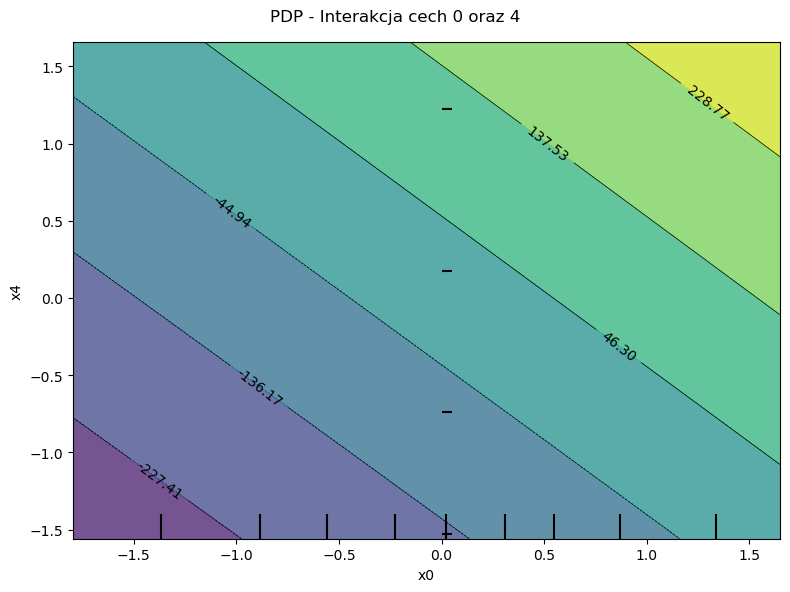

In [ ]:
#Partial Dependence Plots
#w jaki sposob ta cecha wpływa na ostateczną predykcję
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.base import BaseEstimator, RegressorMixin

X, y = make_regression(n_samples=5000, n_features=20)
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_tensor, y_tensor, test_size=0.2
)

class PyTorchRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, epochs=150, lr=0.01):
        self.epochs = epochs
        self.lr = lr
        self.model = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
        
    def fit(self, X, y):
        X_t = torch.as_tensor(X, dtype=torch.float32)
        y_t = torch.as_tensor(y, dtype=torch.float32).view(-1, 1) 
        
        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.model.parameters(), lr=self.lr)
        
        for epoch in range(self.epochs):
            optimizer.zero_grad()
            outputs = self.model(X_t)
            loss = criterion(outputs, y_t)
            loss.backward()
            optimizer.step()
            
        self.is_fitted_ = True 
        
        return self
        
    def predict(self, X):
        X_t = torch.as_tensor(X, dtype=torch.float32)
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(X_t)
            return outputs.view(-1).numpy()

reg = PyTorchRegressorWrapper(epochs=150)
reg.fit(X_train_val.numpy(), y_train_val.numpy())

r = permutation_importance(reg, X_test.numpy(), y_test.numpy(), n_repeats=10, random_state=0)

top_features_idx = np.argsort(r.importances_mean)[::-1][:3]
print(f"Najbardziej istotne cechy to indeksy: {top_features_idx}")


fig, ax = plt.subplots(figsize=(14, 5))
PartialDependenceDisplay.from_estimator(
    estimator=reg, 
    X=X_test.numpy(), 
    features=top_features_idx,
    ax=ax,
    grid_resolution=50
)


plt.suptitle("Wykresy częściowej zależności (PDP) dla 3 najważniejszych cech")
plt.tight_layout()
plt.show()

fig, ax2 = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    estimator=reg, 
    X=X_test.numpy(), 
    features=[(top_features_idx[0], top_features_idx[1])],
    ax=ax2,
    grid_resolution=50
)
plt.suptitle(f"PDP - Interakcja cech {top_features_idx[0]} oraz {top_features_idx[1]}")
plt.tight_layout()
plt.show()